In [8]:
import pandas as od
import numpy as np
from mlxtend.plotting import plot_decision_regions
import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from sklearn.datasets import make_moons
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
X,y=make_moons(n_samples=100,noise=0.1,random_state=1)

<Axes: >

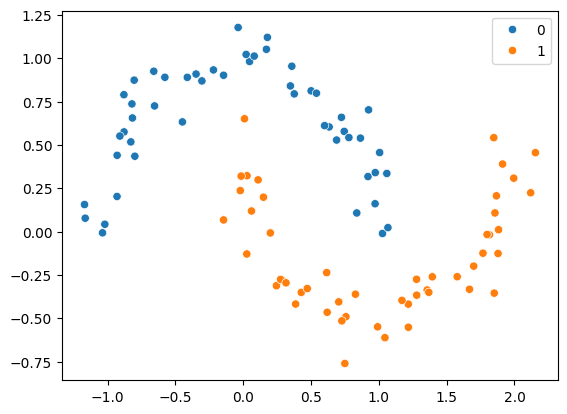

In [11]:
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y)

In [12]:
model=Sequential()

model.add(Dense(10,input_dim=2,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127 (508.00 B)

 Trainable params: 127 (508.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.get_weights()[0:]

[array([[-0.44220135,  0.02255803,  0.10759097, -0.3243045 , -0.3256301 ,
          0.03469932, -0.01083779, -0.17898482, -0.2909685 , -0.6057136 ],
        [-0.44605544,  0.6947411 , -0.21724004, -0.3070506 , -0.03512365,
          0.16073811, -0.6049155 , -0.6657243 , -0.00368768, -0.45058084]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.5464345 , -0.38051522,  0.47000945,  0.4521606 , -0.06596208,
         -0.0360285 ,  0.17249435, -0.03679025],
        [-0.16774112, -0.1683622 , -0.50409704, -0.5490103 , -0.3045748 ,
         -0.4358837 ,  0.3901385 , -0.26736784],
        [ 0.37740028,  0.27230513, -0.276214  ,  0.5215802 , -0.50396615,
          0.03966564,  0.23689139, -0.41096514],
        [-0.43145463, -0.37236834, -0.35265616,  0.357813  ,  0.44587362,
          0.5364717 , -0.4700327 ,  0.38165015],
        [ 0.00645268,  0.28964216,  0.07400447,  0.11522013, -0.19084793,
          0.13129759,  0.29527354, -0.4902458 ]

In [25]:

intial_weights=model.get_weights()


In [26]:
#Zero Weights initialization


intial_weights[0]=np.zeros(model.get_weights()[0].shape)
intial_weights[1]=np.zeros(model.get_weights()[1].shape)
intial_weights[2]=np.zeros(model.get_weights()[2].shape)
intial_weights[3]=np.zeros(model.get_weights()[3].shape)
intial_weights[4]=np.zeros(model.get_weights()[4].shape)
intial_weights[5]=np.zeros(model.get_weights()[5].shape)

In [36]:
model.set_weights(intial_weights)

In [38]:
model.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [39]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [40]:
model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 574ms/step - accuracy: 0.4875 - loss: 0.6931 - val_accuracy: 0.3500 - val_loss: 0.6935
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5375 - loss: 0.6930 - val_accuracy: 0.3500 - val_loss: 0.6939
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5375 - loss: 0.6930 - val_accuracy: 0.3500 - val_loss: 0.6942
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5375 - loss: 0.6929 - val_accuracy: 0.3500 - val_loss: 0.6944
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5375 - loss: 0.6928 - val_accuracy: 0.3500 - val_loss: 0.6946
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5375 - loss: 0.6928 - val_accuracy: 0.3500 - val_loss: 0.6948
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5375 - loss: 0.6928 - val_accuracy: 0.3500 - val_loss: 0.6950
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5375 - loss: 0.6927 - val_accuracy: 0.3500 - val_loss

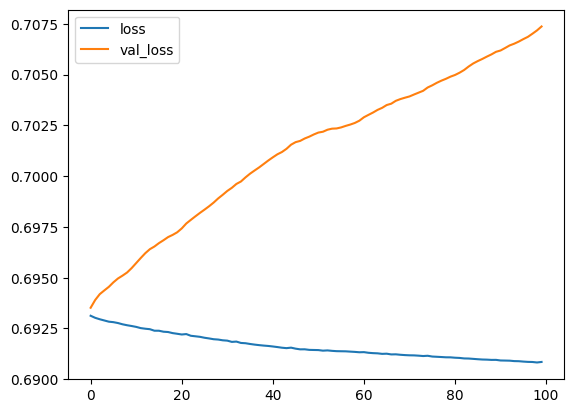

In [43]:
plt.plot(model.history.history['loss'],label="loss")
plt.plot(model.history.history['val_loss'],label='val_loss')
plt.legend()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

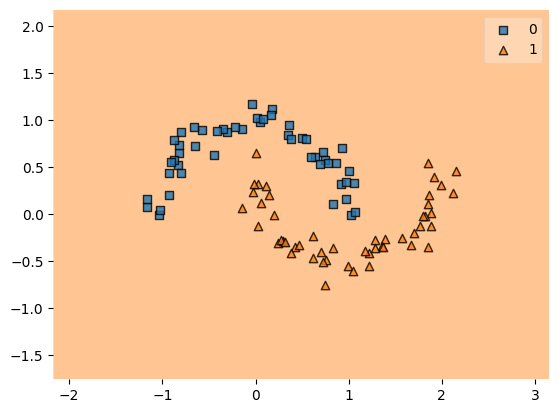

In [44]:
plot_decision_regions(X,y,clf=model)

In [45]:
X,y=make_moons(n_samples=100,noise=0.1,random_state=1)

In [46]:
model=Sequential()

model.add(Dense(10,input_dim=2,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:

intial_weights=model.get_weights()


In [94]:
#ones Weights initialization


intial_weights[0]=np.ones(model.get_weights()[0].shape)
intial_weights[1]=np.ones(model.get_weights()[1].shape)
intial_weights[2]=np.ones(model.get_weights()[2].shape)
intial_weights[3]=np.ones(model.get_weights()[3].shape)
intial_weights[4]=np.ones(model.get_weights()[4].shape)
intial_weights[5]=np.ones(model.get_weights()[5].shape)

In [51]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [52]:
model.fit(X,y,validation_split=0.2,epochs=100)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 452ms/step - accuracy: 0.4625 - loss: 0.6981 - val_accuracy: 0.6500 - val_loss: 0.6521
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4625 - loss: 0.6921 - val_accuracy: 0.6500 - val_loss: 0.6491
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4625 - loss: 0.6861 - val_accuracy: 0.6500 - val_loss: 0.6460
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4625 - loss: 0.6802 - val_accuracy: 0.6500 - val_loss: 0.6429
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4625 - loss: 0.6750 - val_accuracy: 0.6500 - val_loss: 0.6401
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4625 - loss: 0.6693 - val_accuracy: 0.6500 - val_loss: 0.6372
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4750 - loss: 0.6639 - val_accuracy: 0.6500 - val_loss: 0.6342
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4750 - loss: 0.6590 - val_accuracy: 0.6500 - val_loss

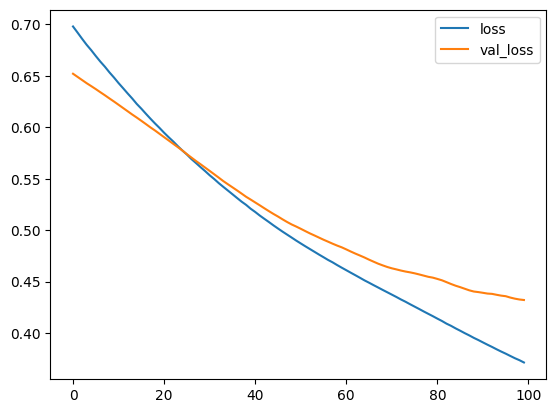

In [53]:
plt.plot(model.history.history['loss'],label="loss")
plt.plot(model.history.history['val_loss'],label='val_loss')
plt.legend()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

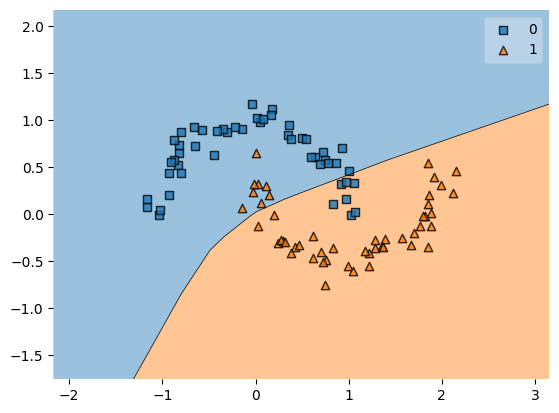

In [54]:
plot_decision_regions(X,y,clf=model)

In [76]:
X,y=make_moons(n_samples=100,noise=0.1,random_state=1)

In [85]:
model=Sequential()

model.add(Dense(10,input_dim=2,activation='tanh'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [86]:

intial_weights=model.get_weights()


In [95]:
#random Weights initialization


intial_weights[0]=np.random.rand(model.get_weights()[0].shape[0],model.get_weights()[0].shape[1])*0.01
intial_weights[1]=np.zeros(model.get_weights()[1].shape)
intial_weights[2]=np.random.rand(model.get_weights()[2].shape[0],model.get_weights()[2].shape[1])*0.01
intial_weights[3]=np.zeros(model.get_weights()[3].shape)
intial_weights[4]=np.random.rand(model.get_weights()[4].shape[0],model.get_weights()[4].shape[1])*0.01
intial_weights[5]=np.zeros(model.get_weights()[5].shape)

In [88]:
model.get_weights()[1].shape[0]

10

In [89]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [90]:
model.fit(X,y,validation_split=0.2,epochs=100)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 455ms/step - accuracy: 0.3250 - loss: 0.7379 - val_accuracy: 0.1500 - val_loss: 0.7993
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3625 - loss: 0.7285 - val_accuracy: 0.1000 - val_loss: 0.7939
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4000 - loss: 0.7179 - val_accuracy: 0.1000 - val_loss: 0.7873
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4500 - loss: 0.7088 - val_accuracy: 0.1000 - val_loss: 0.7806
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4625 - loss: 0.6995 - val_accuracy: 0.1500 - val_loss: 0.7741
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4750 - loss: 0.6902 - val_accuracy: 0.1500 - val_loss: 0.7686
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5250 - loss: 0.6812 - val_accuracy: 0.2000 - val_loss: 0.7625
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5375 - loss: 0.6721 - val_accuracy: 0.2000 - val_loss

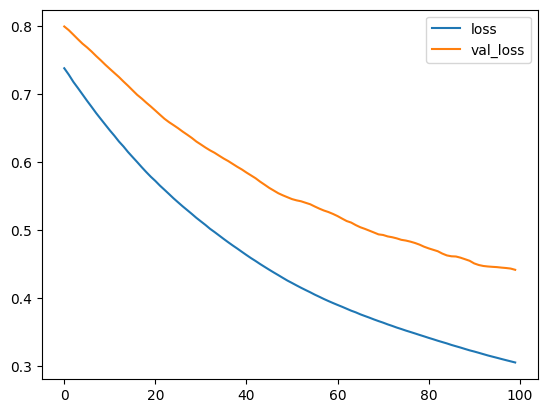

In [91]:
plt.plot(model.history.history['loss'],label="loss")
plt.plot(model.history.history['val_loss'],label='val_loss')
plt.legend()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step


<Axes: >

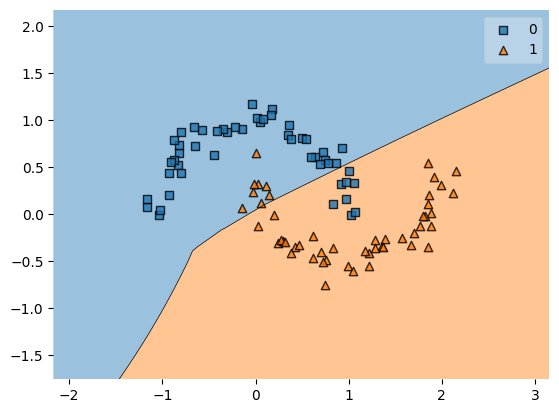

In [92]:
plot_decision_regions(X,y,clf=model)

In [93]:
X,y=make_moons(n_samples=100,noise=0.1,random_state=1)


In [96]:
model=Sequential()

model.add(Dense(10,input_dim=2,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [97]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [98]:
model.fit(X,y,validation_split=0.2,epochs=100)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 535ms/step - accuracy: 0.3875 - loss: 0.7090 - val_accuracy: 0.1000 - val_loss: 0.7660
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4250 - loss: 0.7004 - val_accuracy: 0.1500 - val_loss: 0.7611
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4375 - loss: 0.6928 - val_accuracy: 0.1500 - val_loss: 0.7564
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4500 - loss: 0.6847 - val_accuracy: 0.1500 - val_loss: 0.7521
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4750 - loss: 0.6774 - val_accuracy: 0.1500 - val_loss: 0.7481
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5375 - loss: 0.6699 - val_accuracy: 0.1500 - val_loss: 0.7442
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6000 - loss: 0.6631 - val_accuracy: 0.2000 - val_loss: 0.7405
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6000 - loss: 0.6564 - val_accuracy: 0.3000 - val_loss

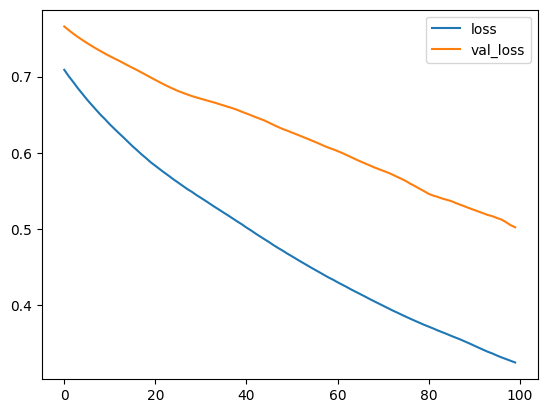

In [99]:
plt.plot(model.history.history['loss'],label="loss")
plt.plot(model.history.history['val_loss'],label='val_loss')
plt.legend()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

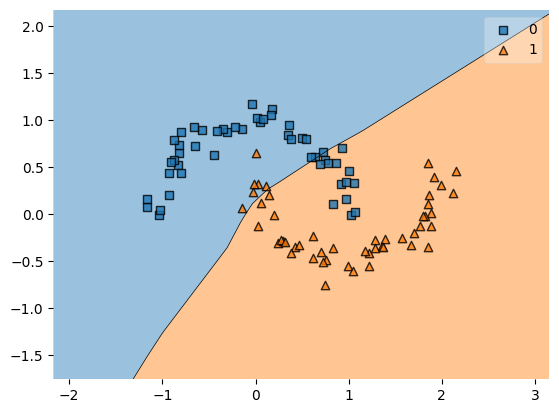

In [100]:
plot_decision_regions(X,y,clf=model)

In [101]:
#conclusion random weights help in better training of model